<a href="https://www.kaggle.com/code/sonawanelalitsunil/india-ipo-trends-2010-2025-ml-100?scriptVersionId=261601936" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ipo-data-india-2010-2025/Initial Public Offering.xlsx


 ## title  📊 India IPO Trends (2010–2025)

## Detailed Description:
This dataset provides comprehensive information on Initial Public Offerings (IPOs) in India from 2010 to 2025. It covers key details such as company names, listing dates, issue prices, subscription data, listing gains, and sectoral insights. The dataset allows analysis of market trends, investor sentiment, sector-wise performance, and the evolution of the IPO market over 15 years. It is useful for researchers, investors, and financial analysts to study patterns in fundraising, identify high-performing IPOs, and assess the changing dynamics of India’s capital markets.

## Import dataset

In [2]:
file_path = "/kaggle/input/ipo-data-india-2010-2025/Initial Public Offering.xlsx"
df = pd.read_excel(file_path)

In [3]:
df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,...,426.15,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,...,199.72,34.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,...,61.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,...,1062.70,57.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,...,150.00,-5.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
556,2010-02-03,Infinite Computer Solutions Limited,189.80,48.44,106.02,11.08,43.22,165,178.35,8.09,...,473.75,187.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
557,2010-01-06,D B Corp Limited,384.22,68.52,26.17,3.42,39.54,212,250.00,17.92,...,273.00,29.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
558,2010-01-05,Godrej Properties Limited,468.85,7.45,0.41,0.38,4.00,490,510.00,4.08,...,1952.10,299.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
559,2010-01-04,JSW Energy Limited,2700.00,2.88,0.15,0.40,1.68,100,102.00,2.00,...,536.40,436.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
560,2010-01-11,MBL Infrastructure Limited,102.60,3.35,2.65,0.40,1.97,180,190.00,5.56,...,40.78,-77.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                561 non-null    datetime64[ns]
 1   IPO_Name            561 non-null    object        
 2   Issue_Size(crores)  561 non-null    float64       
 3   QIB                 559 non-null    float64       
 4   HNI                 559 non-null    float64       
 5   RII                 559 non-null    float64       
 6   Total               559 non-null    float64       
 7   Offer Price         561 non-null    int64         
 8   List Price          561 non-null    float64       
 9   Listing Gain        561 non-null    float64       
 10  CMP(BSE)            559 non-null    float64       
 11  CMP(NSE)            551 non-null    float64       
 12  Current Gains       558 non-null    float64       
 13  Unnamed: 13         0 non-null      float64       

In [6]:
df.dtypes

Date                  datetime64[ns]
IPO_Name                      object
Issue_Size(crores)           float64
QIB                          float64
HNI                          float64
RII                          float64
Total                        float64
Offer Price                    int64
List Price                   float64
Listing Gain                 float64
CMP(BSE)                     float64
CMP(NSE)                     float64
Current Gains                float64
Unnamed: 13                  float64
Unnamed: 14                  float64
Unnamed: 15                  float64
Unnamed: 16                  float64
Unnamed: 17                  float64
Unnamed: 18                  float64
Unnamed: 19                  float64
Unnamed: 20                  float64
dtype: object

In [7]:
df.shape

(561, 21)

In [8]:
df.describe()

,Date,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,561,561.000000,559.000000,559.000000,559.000000,559.000000,561.000000,561.000000,561.000000,559.000000,551.000000,558.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00
mean,2019-02-28 23:00:57.754010880,1411.483957,47.477013,74.686834,15.972165,37.568891,362.187166,430.381480,18.029554,673.822487,687.114047,83.798749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
min,2010-01-04 00:00:00,23.000000,0.000000,0.000000,0.000000,0.110000,10.000000,9.500000,-31.730000,0.040000,0.050000,-99.930000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
25%,2015-05-26 00:00:00,251.190000,2.350000,1.710000,1.600000,2.245000,126.000000,138.000000,-0.010000,119.700000,121.735000,-34.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
50%,2021-02-05 00:00:00,592.000000,13.720000,13.200000,5.120000,11.520000,258.000000,293.000000,7.150000,298.350000,303.200000,14.675000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
75%,2023-11-07 00:00:00,1237.510000,76.255000,81.110000,13.750000,55.070000,493.000000,585.150000,26.130000,741.925000,754.075000,111.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
max,2025-08-06 00:00:00,27858.800000,331.600000,958.070000,374.810000,326.490000,2150.000000,2725.000000,252.760000,15924.100000,15892.000000,2523.670000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2523.67
std,NaN,2642.439572,63.325282,136.785773,33.155961,53.804193,325.282590,416.667277,31.924815,1211.144016,1218.737034,260.180837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

Date                    0
IPO_Name                0
Issue_Size(crores)      0
QIB                     2
HNI                     2
RII                     2
Total                   2
Offer Price             0
List Price              0
Listing Gain            0
CMP(BSE)                2
CMP(NSE)               10
Current Gains           3
Unnamed: 13           561
Unnamed: 14           561
Unnamed: 15           561
Unnamed: 16           561
Unnamed: 17           561
Unnamed: 18           561
Unnamed: 19           561
Unnamed: 20           560
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Date', 'IPO_Name', 'Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Total',
       'Offer Price', 'List Price', 'Listing Gain', 'CMP(BSE)', 'CMP(NSE)',
       'Current Gains', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20'],
      dtype='object')

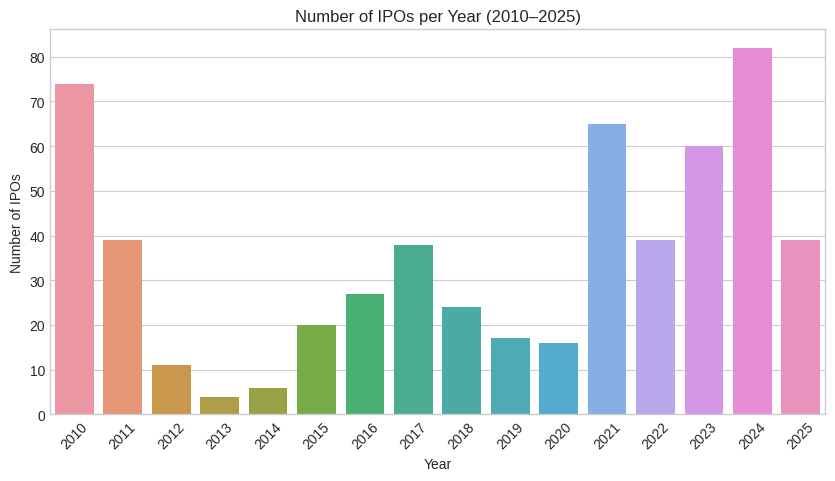

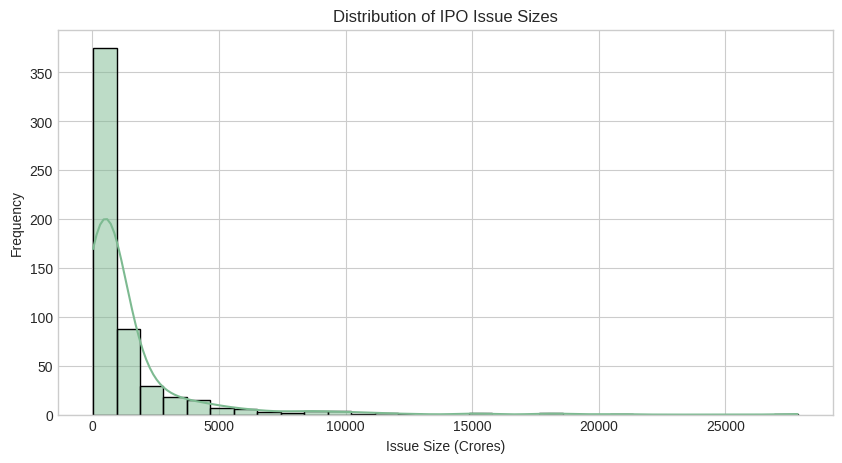

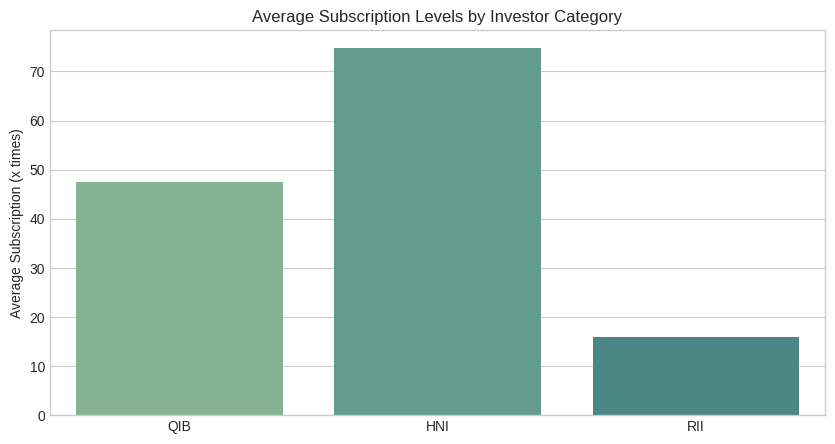

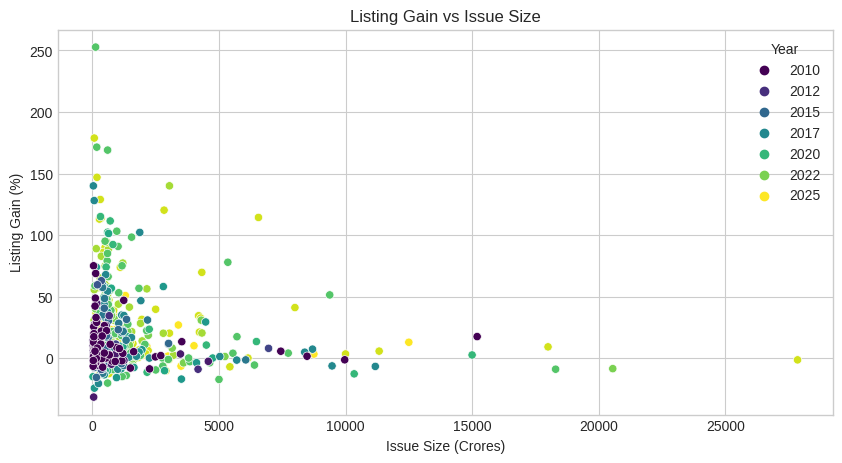

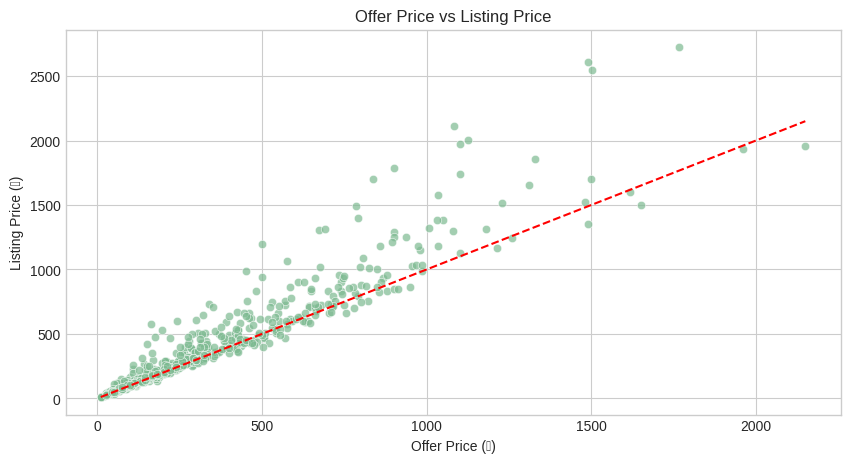

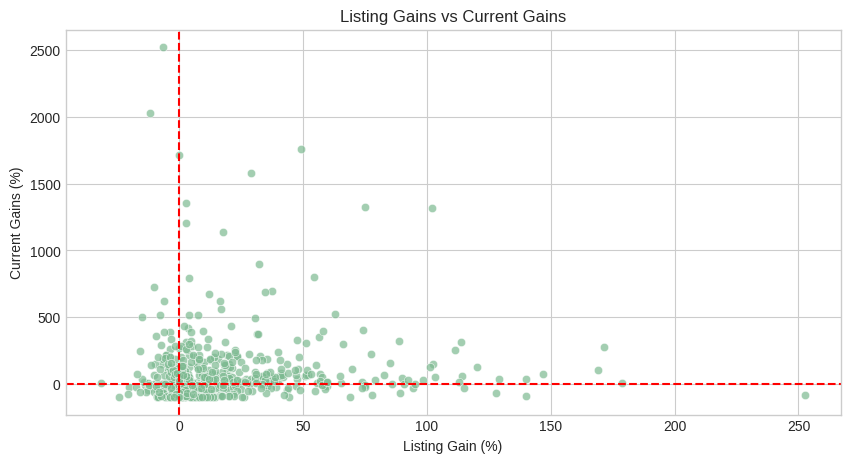

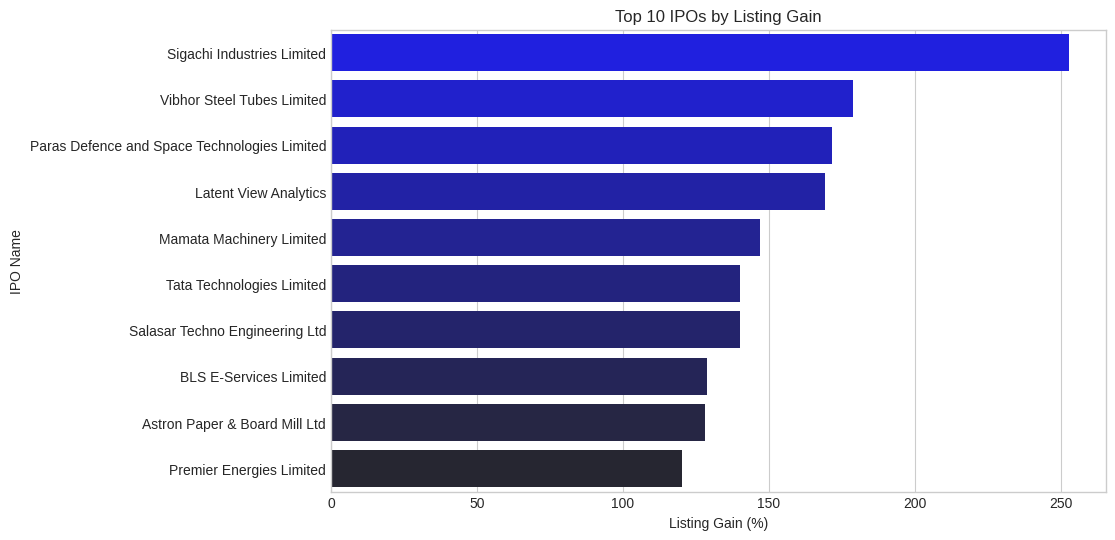

In [12]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

plt.style.use("seaborn-whitegrid")
sns.set_palette("crest")

plt.figure(figsize=(10,5))
ipo_count = df['Year'].value_counts().sort_index()
sns.barplot(x=ipo_count.index, y=ipo_count.values)
plt.title("Number of IPOs per Year (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Number of IPOs")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(df['Issue_Size(crores)'], bins=30, kde=True)
plt.title("Distribution of IPO Issue Sizes")
plt.xlabel("Issue Size (Crores)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
subs_means = df[['QIB', 'HNI', 'RII']].mean()
sns.barplot(x=subs_means.index, y=subs_means.values)
plt.title("Average Subscription Levels by Investor Category")
plt.ylabel("Average Subscription (x times)")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Issue_Size(crores)", y="Listing Gain", hue="Year", data=df, palette="viridis")
plt.title("Listing Gain vs Issue Size")
plt.xlabel("Issue Size (Crores)")
plt.ylabel("Listing Gain (%)")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Offer Price", y="List Price", data=df, alpha=0.7)
plt.plot([df["Offer Price"].min(), df["Offer Price"].max()],
         [df["Offer Price"].min(), df["Offer Price"].max()],
         'r--')  # reference line
plt.title("Offer Price vs Listing Price")
plt.xlabel("Offer Price (₹)")
plt.ylabel("Listing Price (₹)")
plt.show()


plt.figure(figsize=(10,5))
sns.scatterplot(x="Listing Gain", y="Current Gains", data=df, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.axvline(0, color="red", linestyle="--")
plt.title("Listing Gains vs Current Gains")
plt.xlabel("Listing Gain (%)")
plt.ylabel("Current Gains (%)")
plt.show()

top10 = df.nlargest(10, "Listing Gain")[["IPO_Name", "Listing Gain"]]
plt.figure(figsize=(10,6))
sns.barplot(y="IPO_Name", x="Listing Gain", data=top10, palette="dark:blue_r")
plt.title("Top 10 IPOs by Listing Gain")
plt.xlabel("Listing Gain (%)")
plt.ylabel("IPO Name")
plt.show()

## Predictive modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Logistic Regression : 92.73 %
Decision Tree       : 100.00 %
Random Forest       : 100.00 %
Gradient Boosting   : 100.00 %
SVM                 : 88.18 %
KNN                 : 81.82 %


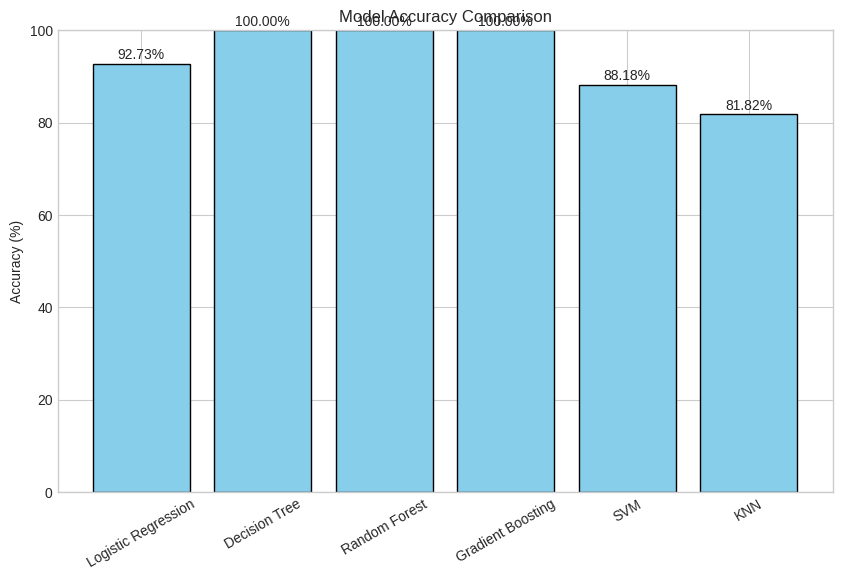

In [14]:
# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Handle missing values
df = df.dropna()

# Create target variable: Positive listing gain (1) or not (0)
df['Target'] = (df['Listing Gain'] > 0).astype(int)

# Features (drop non-numeric except IPO_Name)
X = df.drop(columns=['Date', 'IPO_Name', 'Target'])
y = df['Target']

# Encode categorical columns (if any left)
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Models to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Train & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name:20}: {acc:.2f} %")

# Convert results to DataFrame
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Accuracy"], color="skyblue", edgecolor="black")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(0, 100)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+1, f"{v:.2f}%", ha="center")
plt.show()

## Thank you...pls upvote!!!!